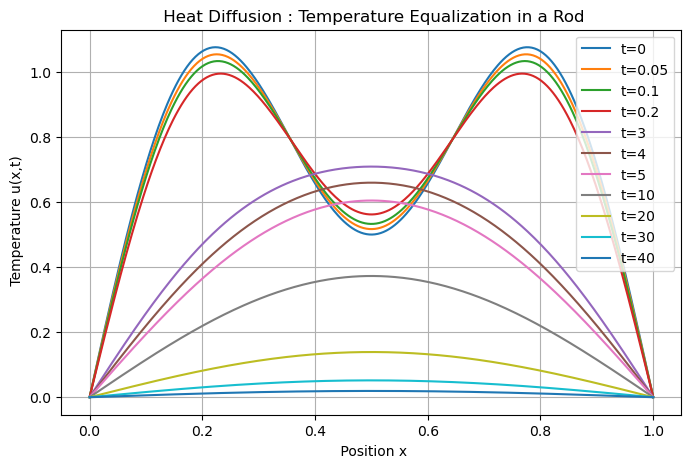

In [8]:
import numpy as np
import matplotlib.pyplot as plt

L = 1
x = np.linspace(0 , L , 400)
alpha = 0.01

# Initial temperature bump
f = lambda x: np.sin(np.pi * x) + 0.5* np.sin (3* np.pi * x)

# Fourier - series solution for Dirichlet BCs
def heat_solution(x , t , N =50):
    u = np.zeros_like(x)
    for n in range(1 , N +1):
        b_n = 2 * np.trapz(f( x ) * np.sin ( n * np . pi * x / L ) , x )
        u += b_n * np.sin(n * np.pi * x / L ) * np.exp(- alpha *( n * np.pi / L) **2* t)
    return u

times = [0 , 0.05 , 0.1 , 0.2, 3, 4, 5, 10, 20, 30, 40]
plt.figure( figsize =(8 ,5))

for t in times:
    plt.plot(x , heat_solution (x , t ) , label = f"t={t}")

plt.title(" Heat Diffusion : Temperature Equalization in a Rod")

plt.xlabel(" Position x")
plt.ylabel("Temperature u(x,t)")
plt.legend()
plt.grid( True )
plt.show()

## 4.6

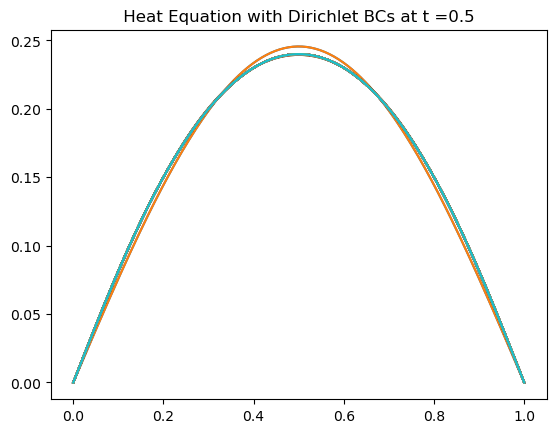

In [10]:
import numpy as np
import matplotlib.pyplot as plt

L = 1
x = np.linspace (0 ,L ,200)
alpha = 0.01
t_final = 0.5
N = 50

f = lambda x: x *(1 - x )
u = np.zeros_like ( x )

for n in range (1 , N +1) :
    b_n = 2 * np.trapz( f ( x ) * np.sin ( n * np.pi * x / L ) , x )
    u += b_n * np.sin( n * np.pi * x / L ) * np.exp( - alpha *( n * np.pi / L) **2* t_final )
    plt.plot(x , u)
plt.title(" Heat Equation with Dirichlet BCs at t =0.5 ")
plt.show()

## 4.7 Nonhomogeneous Heat Equation: Setting and Full Solution

Choose mode ( '1D' or '2D'):  2D


 Stable timestep dt = 8.011537e-05


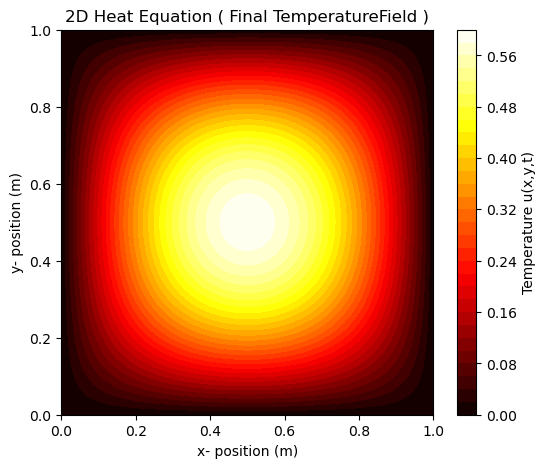

Saved GIF: heat_2d_80 .gif


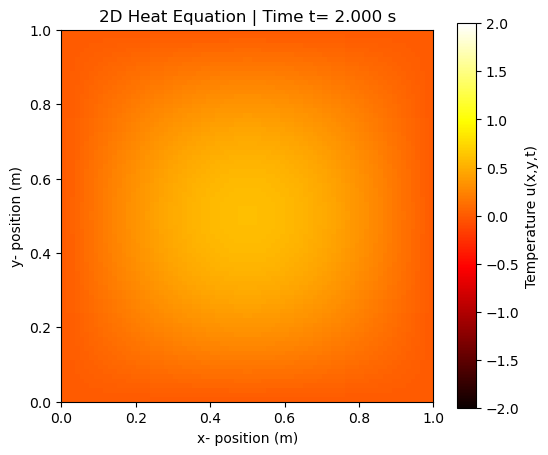

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation ,PillowWriter

#============================================================

# MODE SELECTION
#============================================================

mode = input("Choose mode ( '1D' or '2D'): ").strip().upper()

if mode not in ["1D", "2D"]:
    raise ValueError (" Mode must be ’1D’ or ’2D’")

#============================================================

# PARAMETERS
#============================================================

alpha = 0.1 # thermal diffusivity
L = 1.0 # domain length
T = 2.0 # total time

nx = 20 #80
ny = 20 #80
frameskip = 20

# Stable timestep ( prevents NaN explosion )
dx = L / ( nx - 1)
dt = 0.2 * dx **2 / (4 * alpha )

print( f" Stable timestep dt = {dt :.6e}")

#============================================================

# FORCING FUNCTION ( nonhomogeneous term )
#============================================================

def forcing_1d(x , t):
    return 5 * np.sin(np.pi * x) * np.exp(- t)

def forcing_2d(x, y, t):
    return 5 * np.sin(np.pi * x ) * np.sin(np.pi * y ) * np.exp( - t )


#============================================================

# INITIAL CONDITIONS

#============================================================

def initial_1d( x ):
    return np.sin(2 * np.pi * x )

def initial_2d(X , Y):
    return np.sin (2 * np.pi * X ) * np.sin (2 * np.pi * Y )


#============================================================

# NUMERICAL SAFETY ( prevents NaN/inf blow -up)
#============================================================

def clean( u ):
    u = np.nan_to_num (u , nan =0.0 , posinf =0.0 , neginf=0.0)
    return np.clip(u , -10 , 10)

#============================================================

# 1D SOLVER
#============================================================

def solve_1d():
    x = np.linspace(0 , L , nx)
    u = initial_1d( x )
    u_new = u.copy()

    snapshots = []
    steps = int( T / dt )

    for n in range( steps ):
        t = n * dt

        for i in range(1 , nx - 1):
            lap = ( u [ i +1] - 2* u [ i ] + u [i -1])/ dx **2
            u_new [ i ] = u [ i ] + dt * ( alpha *lap + forcing_1d (x[ i ] , t))

        # Dirichlet boundary conditions
        u_new [0] = 0
        u_new [-1] = 0

        u[:] = clean( u_new )

        if n % frameskip == 0:
            snapshots.append(u.copy())

    return x , snapshots

#============================================================

# 2D SOLVER
#============================================================

def solve_2d():
    x = np.linspace(0 , L , nx )
    y = np.linspace(0 , L , ny )
    X , Y = np.meshgrid(x , y )

    u = initial_2d(X , Y )
    u_new = u.copy()

    snapshots = []
    steps = int( T / dt )

    for n in range( steps ):
        t = n * dt

        for i in range(1 , nx - 1):
            for j in range(1 , ny - 1):
                lap = ((u[j , i +1] - 2* u[j , i] + u[j , i-1]) / dx **2 +
                       (u[ j +1 , i] - 2* u[j , i] + u[j -1 , i]) / dx **2)

                u_new[j , i] = u[j , i] + dt * (alpha * lap + forcing_2d ( x [ i ] , y [j ] , t ))

        # Dirichlet boundaries (T = 0 at edges )
        u_new[0 , :] = 0
        u_new[ -1 , :] = 0
        u_new[: , 0] = 0
        u_new[: , -1] = 0

        u[:] = clean( u_new )

        if n % frameskip == 0:
            snapshots.append(u.copy())

    return X , Y , snapshots

#============================================================

# 1D RUN ( PLOTS + ANIMATION + GIF)
#============================================================

def run_1d():
    x , snaps = solve_1d()
    # ---------------- FINAL SNAPSHOT----------------
    plt.figure(figsize =(7 , 4))
    plt.plot (x , snaps [ -1], label =" Final TemperatureProfile")

    plt.title("1D Heat Equation ( Final State )")
    plt.xlabel("Position x (m)")
    plt.ylabel("Temperature u(x,t)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------- ANIMATION ----------------
    fig , ax = plt.subplots( figsize =(7 , 4) )
    line , = ax.plot(x , snaps [0] , color ="red")

    ax.set_title("1D Heat Diffusion Over Time ")
    ax.set_xlabel(" Position x (m)")
    ax.set_ylabel(" Temperature u(x,t)")
    ax.set_ylim( -2 , 2)
    ax.grid( True )

    def update( i ):
        line.set_ydata( snaps [ i ])
        ax.set_title( f"1D Heat Equation | Time t= {i * dt * frameskip :.3f} s")

        return line ,

    anim = FuncAnimation( fig , update , frames =len(snaps ) , interval =50)


    # SAVE GIF
    anim.save("heat_1d .gif", writer = PillowWriter ( fps=20) )

    print("Saved GIF: heat_1d_essai .gif")

    plt.show()
    return anim

#============================================================

# 2D RUN ( PLOTS + ANIMATION + GIF)
#============================================================

def run_2d():
    X , Y, snaps = solve_2d()

    # ---------------- FINAL SNAPSHOT----------------
    plt.figure( figsize =(6 , 5))
    plt.contourf(X , Y , snaps [ -1] , levels =30 , cmap ="hot")
    
    plt.title("2D Heat Equation ( Final TemperatureField )")
    
    plt.xlabel("x- position (m)")
    plt.ylabel ("y- position (m)")
    cbar = plt.colorbar()
    cbar.set_label("Temperature u(x,y,t)")
    plt.show()
    
    # ---------------- ANIMATION ----------------
    fig , ax = plt.subplots( figsize =(6 , 5))
    
    im = ax.imshow(
        snaps[0],
        origin ="lower",
        cmap ="hot", 
        vmin = -2,
        vmax =2,
        extent =[0 , L , 0 , L ]
        )

    cbar = plt.colorbar(im , ax = ax)
    cbar.set_label("Temperature u(x,y,t)")
    
    ax.set_title("2D Heat Diffusion Over Time")
    ax.set_xlabel("x- position (m)")
    ax.set_ylabel("y- position (m)")
    
    def update(i):
        im.set_array( snaps [ i ])
        ax.set_title( f"2D Heat Equation | Time t= {i * dt * frameskip :.3f} s")
    
        return [im]
    
    anim = FuncAnimation(fig , update, frames =len(snaps ), interval =50)

    # SAVE GIF
    anim.save("heat_2d.gif", writer = PillowWriter( fps=20) )
    
    print ("Saved GIF: heat_2d_essai .gif")
    
    plt.show()
    return anim

#============================================================

# RUN PROGRAM
#============================================================

if mode == "1D":
    animation = run_1d()
else:
    animation = run_2d()